In [78]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc


In [2]:
df=pd.read_csv('C:/Users/abrup/Desktop/Project/survival-analysis/data/processed/top_20_genes_survival_data.csv')

In [3]:
df

,Patient_ID,CD44,GSTP1,IFITM3,GPRC5A,SCGB1B2P,CRYBG1,IGHG3,DDR1,MT-RNR2,...,TNC,EFEMP1,PBX1,S100A11,CD81,S100A9,SPP1,FOS,time,event
0,0,0.467144,-0.409501,1.112887,0.791900,5.363893,0.888832,2.187349,-1.115790,-0.524356,...,-0.033789,0.548173,1.310858,0.991080,0.397376,0.458505,0.518122,-0.880487,3959.0,1
1,1,0.454776,-0.159768,-0.303420,-0.371377,0.263928,-0.110478,0.931092,-0.699474,-1.548765,...,-0.583797,-0.177882,0.779818,0.407760,0.103374,-0.245938,-1.623564,-1.033991,2965.0,1
2,2,0.977865,1.072303,-1.914388,0.795906,-0.381069,-2.432660,-1.613441,0.446688,-0.730537,...,-2.203938,-2.010211,0.563656,-2.442809,-2.240439,-1.229013,0.239873,-0.251100,377.0,1
3,3,-1.244080,1.409944,-0.488531,-0.538240,-0.998113,0.456657,0.348532,0.326569,-0.914706,...,2.248809,1.157220,-1.824979,0.427381,-0.510680,1.114703,2.228154,0.254938,239.0,1
4,4,0.950066,0.596614,0.382809,-0.451939,0.065328,0.878355,-0.576284,-0.898128,1.137397,...,1.165954,1.734998,0.095166,0.359642,1.182477,0.291822,-0.216480,0.523495,2965.0,1
5,5,-0.660981,0.255809,-1.116267,-1.179336,-0.446866,0.434647,0.440220,-0.432324,-1.151923,...,0.209361,0.630672,-0.982226,-1.294848,-0.085014,0.066798,-0.625048,0.490977,678.0,1
6,6,-1.582673,0.505526,-0.256127,-0.704783,0.157511,-2.223726,-1.764151,1.317943,0.750777,...,-2.887190,1.005395,0.051465,-0.791638,-0.687300,-1.625911,1.181663,-1.051815,0.0,1
7,7,0.290030,-1.100307,0.588709,1.159825,-0.693095,0.145943,0.289372,0.347873,0.355432,...,-0.055182,-0.131385,0.878472,-0.026486,-0.892263,0.511120,-0.043040,-0.545343,1694.0,1
8,8,-0.601955,0.938176,-0.056820,-1.027843,0.606642,-0.279523,-0.284116,-0.952931,-0.069602,...,-0.245306,0.008847,-1.925223,-0.378981,0.475846,0.241568,-1.060051,1.624169,1556.0,1
9,9,0.470737,0.681711,0.132223,-1.037879,1.621227,0.935267,-0.317123,-0.602574,1.170778,...,0.628081,1.183598,0.242561,-0.285534,0.851973,0.751666,-0.723419,0.597312,0.0,1


In [15]:
x_ml=df.drop(["Patient_ID","time","event"],axis=1)

In [16]:
x_ml

,CD44,GSTP1,IFITM3,GPRC5A,SCGB1B2P,CRYBG1,IGHG3,DDR1,MT-RNR2,IGSF1,S100A7,RPL12,TNC,EFEMP1,PBX1,S100A11,CD81,S100A9,SPP1,FOS
0,0.467144,-0.409501,1.112887,0.791900,5.363893,0.888832,2.187349,-1.115790,-0.524356,-1.006416,0.670204,2.398978,-0.033789,0.548173,1.310858,0.991080,0.397376,0.458505,0.518122,-0.880487
1,0.454776,-0.159768,-0.303420,-0.371377,0.263928,-0.110478,0.931092,-0.699474,-1.548765,0.056342,-1.084590,-0.484225,-0.583797,-0.177882,0.779818,0.407760,0.103374,-0.245938,-1.623564,-1.033991
2,0.977865,1.072303,-1.914388,0.795906,-0.381069,-2.432660,-1.613441,0.446688,-0.730537,-2.038302,-0.271650,-1.110499,-2.203938,-2.010211,0.563656,-2.442809,-2.240439,-1.229013,0.239873,-0.251100
3,-1.244080,1.409944,-0.488531,-0.538240,-0.998113,0.456657,0.348532,0.326569,-0.914706,-1.200919,0.045376,0.220285,2.248809,1.157220,-1.824979,0.427381,-0.510680,1.114703,2.228154,0.254938
4,0.950066,0.596614,0.382809,-0.451939,0.065328,0.878355,-0.576284,-0.898128,1.137397,1.085813,0.327068,-0.077121,1.165954,1.734998,0.095166,0.359642,1.182477,0.291822,-0.216480,0.523495
5,-0.660981,0.255809,-1.116267,-1.179336,-0.446866,0.434647,0.440220,-0.432324,-1.151923,1.116188,0.045376,0.329877,0.209361,0.630672,-0.982226,-1.294848,-0.085014,0.066798,-0.625048,0.490977
6,-1.582673,0.505526,-0.256127,-0.704783,0.157511,-2.223726,-1.764151,1.317943,0.750777,-0.708135,-0.813610,0.136628,-2.887190,1.005395,0.051465,-0.791638,-0.687300,-1.625911,1.181663,-1.051815
7,0.290030,-1.100307,0.588709,1.159825,-0.693095,0.145943,0.289372,0.347873,0.355432,1.118158,-0.542630,-1.639780,-0.055182,-0.131385,0.878472,-0.026486,-0.892263,0.511120,-0.043040,-0.545343
8,-0.601955,0.938176,-0.056820,-1.027843,0.606642,-0.279523,-0.284116,-0.952931,-0.069602,1.093313,-0.813610,2.030871,-0.245306,0.008847,-1.925223,-0.378981,0.475846,0.241568,-1.060051,1.624169
9,0.470737,0.681711,0.132223,-1.037879,1.621227,0.935267,-0.317123,-0.602574,1.170778,0.053019,1.156811,1.220664,0.628081,1.183598,0.242561,-0.285534,0.851973,0.751666,-0.723419,0.597312


In [17]:
x_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD44      41 non-null     float64
 1   GSTP1     41 non-null     float64
 2   IFITM3    41 non-null     float64
 3   GPRC5A    41 non-null     float64
 4   SCGB1B2P  41 non-null     float64
 5   CRYBG1    41 non-null     float64
 6   IGHG3     41 non-null     float64
 7   DDR1      41 non-null     float64
 8   MT-RNR2   41 non-null     float64
 9   IGSF1     41 non-null     float64
 10  S100A7    41 non-null     float64
 11  RPL12     41 non-null     float64
 12  TNC       41 non-null     float64
 13  EFEMP1    41 non-null     float64
 14  PBX1      41 non-null     float64
 15  S100A11   41 non-null     float64
 16  CD81      41 non-null     float64
 17  S100A9    41 non-null     float64
 18  SPP1      41 non-null     float64
 19  FOS       41 non-null     float64
dtypes: float64(20)
memory usage: 6.5 K

In [18]:
y_ml=df[["time","event"]]

In [19]:
y_ml

,time,event
0,3959.0,1
1,2965.0,1
2,377.0,1
3,239.0,1
4,2965.0,1
5,678.0,1
6,0.0,1
7,1694.0,1
8,1556.0,1
9,0.0,1


In [20]:
median_time = y["time"].median()

In [21]:
risk_label = (y["time"] < median_time).astype(int)

In [38]:
y_ml=risk_label

In [39]:
y_ml

0     0
1     0
2     1
3     1
4     0
5     1
6     1
7     0
8     0
9     1
10    1
11    0
12    0
13    0
14    0
15    1
16    1
17    1
18    1
19    0
20    0
21    1
22    1
23    1
24    0
25    1
26    1
27    1
28    1
29    0
30    1
31    0
32    0
33    1
34    0
35    0
36    0
37    0
38    0
39    0
40    1
Name: time, dtype: int64

#### Train/Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    x_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    x_ml,
    y_ml,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())

ROC-AUC scores: [0.7    0.8125 0.8125 0.875  0.75  ]
Mean ROC-AUC: 0.79


#### XGBoost

In [29]:
%pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/101.7 MB 812.7 kB/s eta 0:02:06
   ---------------------------------------- 0.1/101.7 MB 1.0 MB/s eta 0:01:39
   ---------------------------------------- 0.3/101.7 MB 1.6 MB/s eta 0:01:05
   ---------------------------------------- 0.3/101.7 MB 1.6 MB/s eta 0:01:05
   ---------------------------------------- 0.4/101.7 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 0.6/101.7 MB 1.9 MB/s eta 0:00:53
   ---------------------------------------- 0.7/101.7 MB 2.1 MB/s eta 0:00:50
   ---------------------------------------- 0.8/101.7 MB 2.1 MB/s eta 0:00:47
   ------------------------


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
X_train

,CD44,GSTP1,IFITM3,GPRC5A,SCGB1B2P,CRYBG1,IGHG3,DDR1,MT-RNR2,IGSF1,S100A7,RPL12,TNC,EFEMP1,PBX1,S100A11,CD81,S100A9,SPP1,FOS
6,-1.582673,0.505526,-0.256127,-0.704783,0.157511,-2.223726,-1.764151,1.317943,0.750777,-0.708135,-0.813610,0.136628,-2.887190,1.005395,0.051465,-0.791638,-0.687300,-1.625911,1.181663,-1.051815
26,0.314976,-0.660898,-0.582514,0.527316,-0.645466,0.691472,-2.264449,1.285471,0.721533,-1.267254,2.127208,-1.443173,0.814714,-0.211061,1.134283,-1.370460,-0.241350,1.930997,2.255299,0.095964
12,0.482443,0.012060,0.308549,0.589518,-0.381069,0.887674,0.866492,1.072035,0.513360,-0.589255,0.045376,0.846037,1.699016,0.257806,0.822621,0.739547,0.686561,-0.272435,-0.530082,0.647207
17,-0.651015,2.356934,-1.186297,-0.557507,-0.799513,-0.109800,-0.893151,0.336615,-0.109494,0.109229,-0.225604,0.379125,-0.444572,-0.695011,-0.366668,1.517136,-0.777606,0.948434,1.366014,-0.616206
9,0.470737,0.681711,0.132223,-1.037879,1.621227,0.935267,-0.317123,-0.602574,1.170778,0.053019,1.156811,1.220664,0.628081,1.183598,0.242561,-0.285534,0.851973,0.751666,-0.723419,0.597312
15,-0.142313,0.217040,-0.528030,-1.373410,-0.482276,-0.105964,-1.683250,-3.196219,-0.882442,0.292406,-1.084590,-1.803728,-0.391966,1.337581,-1.547185,-0.604526,0.957387,0.310731,0.335763,1.508517
32,-0.772511,-0.814500,0.486280,0.382239,0.397963,-0.398998,-0.492688,0.892251,0.316870,0.537846,-0.455394,0.496788,-0.461039,-0.451643,-1.012066,-0.184882,0.149031,-0.090453,-1.131828,0.865299
16,-1.272431,1.108845,0.458848,-0.061894,-0.645466,-0.734431,0.661917,-0.734011,0.559714,-0.604355,-1.084590,0.136223,1.214958,0.632831,0.233821,2.216640,0.204088,0.201106,-0.926122,-1.077366
35,-2.277062,-1.557580,0.601233,-0.500064,-0.080549,2.441177,0.559095,-0.704390,-1.844557,-1.200919,-1.084590,0.317098,-0.281134,-1.800156,1.091821,-0.391677,-1.879197,-0.687445,-1.277075,-1.489227
34,1.482571,-0.317427,0.801466,1.542966,0.311557,0.108988,0.443805,0.792635,0.176841,0.243867,-0.271650,1.230791,0.086498,-1.176227,1.497666,0.580619,0.140949,-0.387361,-0.488663,-1.661386


In [42]:
y_train

6     1
26    1
12    0
17    1
9     1
15    1
32    0
16    1
35    0
34    0
0     0
27    1
5     1
11    0
1     0
30    1
21    1
2     1
31    0
37    0
3     1
36    0
23    1
33    1
10    1
22    1
18    1
20    0
7     0
14    0
28    1
38    0
Name: time, dtype: int64

In [58]:
xgb = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [59]:
#predictions

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

In [60]:
y_prob

array([0.17834646, 0.6791235 , 0.814844  , 0.7065647 , 0.830268  ,
       0.7018131 , 0.31756526, 0.87165636, 0.18858981], dtype=float32)

In [61]:
#Accuracy

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7777777777777778


In [62]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.67      1.00      0.80         4

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9



In [63]:
print("ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())

ROC-AUC scores: [0.7    0.8125 0.8125 0.875  0.75  ]
Mean ROC-AUC: 0.79


In [64]:
scores
scores.mean()

np.float64(0.79)

#### Random Forest

In [67]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_scores = cross_val_score(
    rf,
    x_ml,
    y_ml,
    cv=5,
    scoring="roc_auc"
)

print("RF ROC-AUC scores:", rf_scores)
print("RF Mean ROC-AUC:", rf_scores.mean())

RF ROC-AUC scores: [0.6    0.8125 0.9375 0.4375 0.75  ]
RF Mean ROC-AUC: 0.7075


#### Neural Network

In [70]:
nn = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500)

nn_scores = cross_val_score(
    nn,
    x_ml,
    y_ml,
    cv=5,
    scoring="roc_auc"
)

print("NN Mean ROC-AUC:", nn_scores.mean())

NN Mean ROC-AUC: 0.7625


In [72]:
#Which of these genes actually matters the most for predicting patient survival?"
importance = pd.Series(xgb.feature_importances_, index=x_ml.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

SCGB1B2P    0.164108
EFEMP1      0.134836
GPRC5A      0.087433
IFITM3      0.080188
CD44        0.062636
IGSF1       0.057721
GSTP1       0.057030
S100A11     0.051566
SPP1        0.047573
FOS         0.045519
dtype: float32


In [73]:


# XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, eval_metric="logloss")
xgb.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(X_train, y_train)

# Neural Network
nn = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500)
nn.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [74]:
xgb_prob = xgb.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
nn_prob = nn.predict_proba(X_test)[:, 1]

In [76]:


# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = auc(fpr_rf, tpr_rf)

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)
auc_nn = auc(fpr_nn, tpr_nn)

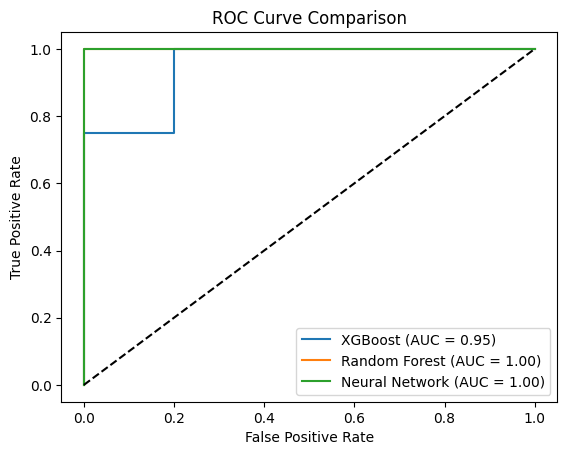

In [79]:


plt.figure()

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.2f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()